# 共通準備 Notebook：1次元拡散方程式

対応章: [`../chapters/10_pde_foundations.md`](../chapters/10_pde_foundations.md)

偏微分方程式を空間差分で大きな連立ODEに変え，陽的Euler法で計算する．安定条件を満たす場合と破る場合を比較する．

## 1. ライブラリとパラメータ

$r=D\Delta t/\Delta x^2\le 1/2$ が1次元陽解法の安定条件である．

In [1]:
import numpy as np
import matplotlib.pyplot as plt

D = 0.1       # diffusion coefficient
L = 1.0       # domain length
nx = 101      # number of grid points
x = np.linspace(0.0, L, nx)
dx = x[1] - x[0]
dt = 0.45 * dx**2 / D  # stable: r = 0.45
t_end = 0.05
r = D * dt / dx**2
print(f'dx={dx:.4f}, dt={dt:.6f}, r={r:.3f}, stable={r <= 0.5}')

dx=0.0100, dt=0.000450, r=0.450, stable=True


## 2. 初期条件と更新関数

中央に置いたガウス分布が拡散する様子を計算する．両端はNeumann条件（流束0）とする．`u.copy()` により，更新前後の時刻を混ぜない．

In [2]:
def initial_condition(x):
    return np.exp(-((x - 0.5) / 0.06) ** 2)

def step_diffusion(u, r):
    u_new = u.copy()
    u_new[1:-1] = u[1:-1] + r * (u[:-2] - 2.0 * u[1:-1] + u[2:])
    u_new[0] = u_new[1]    # du/dx = 0 at x=0
    u_new[-1] = u_new[-2]  # du/dx = 0 at x=L
    return u_new

def solve_diffusion(dt, t_end):
    r = D * dt / dx**2
    u = initial_condition(x)
    snapshots = [(0.0, u.copy())]
    n_steps = int(np.ceil(t_end / dt))
    targets = {n_steps // 4, n_steps // 2, n_steps}
    for n in range(1, n_steps + 1):
        u = step_diffusion(u, r)
        if n in targets:
            snapshots.append((n * dt, u.copy()))
    return r, snapshots


## 3. 安定な計算

拡散によりピークが下がり，分布が広がることを確認する．断熱境界なので，空間積分（総量）はほぼ保存される．

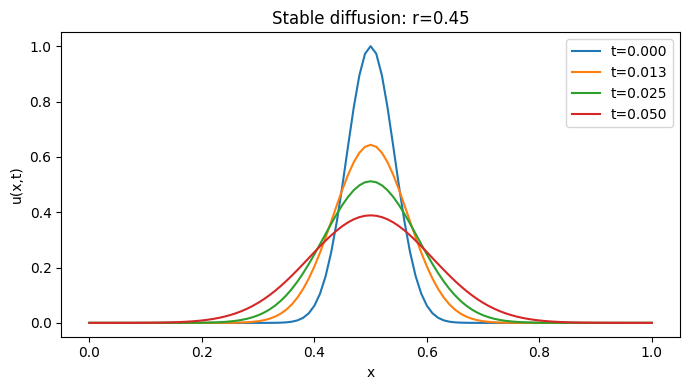

integrals: ['0.106347', '0.106347', '0.106347', '0.106347']


/var/folders/6_/q_c40p295y5566q8kzgt8gdm0000gn/T/ipykernel_19160/1999486317.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  masses = [np.trapz(u, x) for _, u in stable_snapshots]


In [3]:
r_stable, stable_snapshots = solve_diffusion(dt, t_end)
fig, ax = plt.subplots(figsize=(7, 4))
for time, u in stable_snapshots:
    ax.plot(x, u, label=f't={time:.3f}')
ax.set(xlabel='x', ylabel='u(x,t)', title=f'Stable diffusion: r={r_stable:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

masses = [np.trapz(u, x) for _, u in stable_snapshots]
print('integrals:', [f'{mass:.6f}' for mass in masses])

## 4. 安定条件を破る

同じPDEと初期条件でも，$r>1/2$ にすると格子状の振動が増幅する．これは物理現象ではなく数値不安定性である．

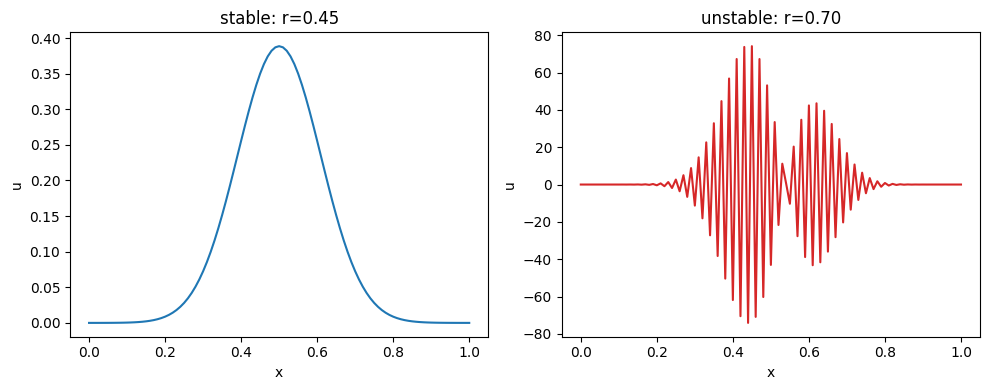

unstable range: [-7.411e+01, 7.413e+01]


In [4]:
dt_unstable = 0.70 * dx**2 / D
r_unstable, unstable_snapshots = solve_diffusion(dt_unstable, t_end)
u_bad = unstable_snapshots[-1][1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(x, stable_snapshots[-1][1])
axes[0].set_title(f'stable: r={r_stable:.2f}')
axes[1].plot(x, u_bad, color='tab:red')
axes[1].set_title(f'unstable: r={r_unstable:.2f}')
for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('u')
plt.tight_layout()
plt.show()
print(f'unstable range: [{u_bad.min():.3e}, {u_bad.max():.3e}]')

## 5. 課題

1. `dt` を変え，どの値から振動が増えるか調べ，理論上の上限と比較する．
2. `nx` を201にして `dx` を半分にする．安定性を保つには `dt` を何倍にすべきか確かめる．
3. Neumann条件を `u_new[0] = u_new[-1] = 0` というDirichlet条件へ変え，総量と長時間後の分布がどう変わるか説明する．
4. 高さが同じで幅の異なる2つの初期分布を比較し，ピーク値と総量のどちらを評価指標にすべきか考える．